# Семинар 10 - Текстурный анализ изображений

***

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from skimage import feature
from skimage.transform import integral_image
import ipywidgets

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from tqdm import tqdm

# Загрузка данных

В рамках данного семинара предлагается поработать с набором данных **Describable Textures Dataset (DTD)** - https://www.robots.ox.ac.uk/~vgg/data/dtd/. Основным заданием будет решить задачу классификации текстур на основе текстурных признаков основанных на полутоновой матрице смежности (GLCM, Grey-Level Co-occurence Matrix).

In [6]:
!wget https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz

--2026-04-20 23:43:26--  https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/dtd/dtd-r1.0.1.tar.gz [following]
--2026-04-20 23:43:27--  https://thor.robots.ox.ac.uk/dtd/dtd-r1.0.1.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 625239812 (596M) [application/octet-stream]
Saving to: ‘dtd-r1.0.1.tar.gz’

dtd-r1.0.1.tar.gz   100%[===================>] 596.27M   694KB/s    in 6m 55s  

2026-04-20 23:50:22 (1.44 MB/s) - ‘dtd-r1.0.1.tar.gz’ saved [625239812/625239812]



In [7]:
!tar -xvf dtd-r1.0.1.tar.gz

dtd/
dtd/labels/
dtd/labels/test2.txt
dtd/labels/train2.txt
dtd/labels/test7.txt
dtd/labels/train3.txt
dtd/labels/train8.txt
dtd/labels/val3.txt
dtd/labels/val8.txt
dtd/labels/train10.txt
dtd/labels/train6.txt
dtd/labels/val2.txt
dtd/labels/test1.txt
dtd/labels/val5.txt
dtd/labels/test10.txt
dtd/labels/train1.txt
dtd/labels/val4.txt
dtd/labels/labels_joint_anno.txt
dtd/labels/test3.txt
dtd/labels/train9.txt
dtd/labels/val6.txt
dtd/labels/train4.txt
dtd/labels/val1.txt
dtd/labels/test8.txt
dtd/labels/test9.txt
dtd/labels/test5.txt
dtd/labels/test4.txt
dtd/labels/train5.txt
dtd/labels/test6.txt
dtd/labels/val10.txt
dtd/labels/train7.txt
dtd/labels/val9.txt
dtd/labels/val7.txt
dtd/images/
dtd/images/perforated/
dtd/images/perforated/perforated_0134.jpg
dtd/images/perforated/perforated_0167.jpg
dtd/images/perforated/perforated_0101.jpg
dtd/images/perforated/perforated_0136.jpg
dtd/images/perforated/perforated_0168.jpg
dtd/images/perforated/perforated_0153.jpg
dtd/images/perforated/perforat

In [2]:
img = cv2.imread('dtd/images/lined/lined_0039.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

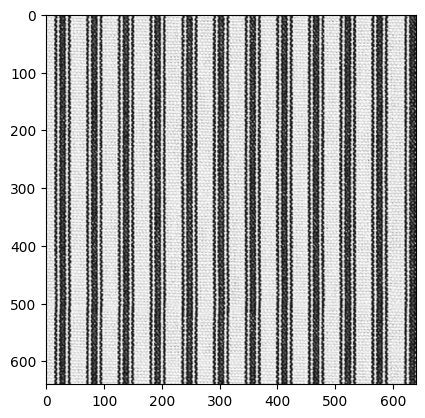

In [3]:
plt.imshow(img_gray, cmap='Greys_r')

# GLCM - Gray Level Co-Occurrence Matrix

Реализацию расчета GLCM и некоторых признаков можно взять из библиотеки skimage:

https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html

In [4]:
import skimage.feature as feature

In [5]:
@ipywidgets.interact(
    distance=ipywidgets.IntSlider(min=1, max=100, step=1, value=1),
    angle=ipywidgets.IntSlider(min=-180, max=180, step=1, value=0)
)
def play_with_glcm(distance, angle):
    glcm = feature.graycomatrix(img_gray, [distance], [angle * np.pi / 180], levels=256)
    plt.imshow(glcm[:, :, 0, 0], cmap='coolwarm')

interactive(children=(IntSlider(value=1, description='distance', min=1), IntSlider(value=0, description='angle…

## Вопрос 1

_(самостоятельная работа без проверки)_

Как по полутоновой матрице смежности определить период текстуры? Чему примерно он равен на рисунке выше (вдоль оси X)?

**Ответ:**

## Вычисление характеристик

- `'contrast'`: $$\sum_{i,j=0}^{levels-1} P_{i,j}(i-j)^2$$
- `'dissimilarity'`: $$\sum_{i,j=0}^{levels-1}P_{i,j}|i-j|$$
- `'homogeneity'`: $$\sum_{i,j=0}^{levels-1}\frac{P_{i,j}}{1+(i-j)^2}$$
- `'ASM'`: $$\sum_{i,j=0}^{levels-1} P_{i,j}^2$$
- `'energy'`: $$\sqrt{ASM}$$
- `'correlation'`: $$\sum_{i,j=0}^{levels-1} P_{i,j}\left[\frac{(i-\mu_i)(j-\mu_j)}{\sqrt{(\sigma_i^2)(\sigma_j^2)}}\right]$$

In [ ]:
glcm = feature.graycomatrix(img_gray, [50], [0], levels=256)

contrast = feature.graycoprops(glcm, 'contrast')
dissimilarity = feature.graycoprops(glcm, 'dissimilarity')
homogeneity = feature.graycoprops(glcm, 'homogeneity')
energy = feature.graycoprops(glcm, 'energy')
correlation = feature.graycoprops(glcm, 'correlation')
ASM = feature.graycoprops(glcm, 'ASM')

print("Contrast: {}".format(contrast))
print("Dissimilarity: {}".format(dissimilarity))
print("Homogeneity: {}".format(homogeneity))
print("Energy: {}".format(energy))
print("Correlation: {}".format(correlation))
print("ASM: {}".format(ASM))

Contrast: [[8769.00970869]]
Dissimilarity: [[69.9390625]]
Homogeneity: [[0.02388795]]
Energy: [[0.00690536]]
Correlation: [[0.15376945]]
ASM: [[4.76839955e-05]]


# Классификация текстур

Сначала определим функцию для загрузки датасета, которая для каждого изображения сразу расчитает его набор признаков:

In [6]:
def load_dtd(path, get_features_fn):
    classes = sorted(os.listdir(os.path.join(path, 'images')))

    rows = []
    name2idx = {}

    for class_name in tqdm(classes):
        folder_path = os.path.join(path, 'images', class_name)
        for img_name in os.listdir(folder_path):
            if not img_name.endswith('.jpg'):
                continue

            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path)
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            features = get_features_fn(img_gray)

            features['class'] = class_name

            name2idx[img_name] = len(rows)
            rows.append(features)

    splits = []

    for split in range(1, 11):
        train_filepath = os.path.join(path, 'labels', 'train{}.txt'.format(split))
        val_filepath = os.path.join(path, 'labels', 'val{}.txt'.format(split))
        test_filepath = os.path.join(path, 'labels', 'test{}.txt'.format(split))

        with open(train_filepath) as f:
            train_ids = list(map(lambda x: name2idx[x.split('/')[-1]], f.read().split()))

        with open(val_filepath) as f:
            val_ids = list(map(lambda x: name2idx[x.split('/')[-1]], f.read().split()))

        with open(test_filepath) as f:
            test_ids = list(map(lambda x: name2idx[x.split('/')[-1]], f.read().split()))

        splits.append((train_ids, val_ids))

    return pd.DataFrame(rows), splits

В качестве примера определим функцию, возвращающую доступные в skimage текстурные характеристики:

In [7]:
def get_features(img_gray):
    dists = [1]
    angles = [np.pi/2]

    props = ['contrast', 'dissimilarity', 'homogeneity',
             'energy', 'correlation', 'ASM']

    graycom = feature.graycomatrix(img_gray, dists, angles, levels=256)

    features = {}
    for prop in props:
        prop_values = feature.graycoprops(graycom, prop)
        for i, dist in enumerate(dists):
            for j, angle in enumerate(angles):
                features[prop + '_{:.3f}_{:.3f}'.format(dist, angle)] = prop_values[i, j]

    return features

In [8]:
df, splits = load_dtd('dtd', get_features)

 45%|████▍     | 21/47 [00:08<00:10,  2.37it/s]


KeyboardInterrupt: 

In [10]:
df.head()

,contrast_1.000_1.571,dissimilarity_1.000_1.571,homogeneity_1.000_1.571,energy_1.000_1.571,correlation_1.000_1.571,ASM_1.000_1.571,class
0,0.000000,0.000000,1.000000,0.215864,1.000000,0.046597,banded
1,9.866287,1.596926,0.602670,0.082382,0.998554,0.006787,banded
2,298.466949,8.181390,0.189166,0.022279,0.970253,0.000496,banded
3,178.034464,6.233053,0.365898,0.047476,0.976954,0.002254,banded
4,55.670543,5.127089,0.225943,0.031131,0.985575,0.000969,banded


In [11]:
df.shape

(5640, 7)

In [12]:
X = df.iloc[:, :-1]
y = df['class']

In [13]:
len(y.unique())

47

В качестве модели попробуем случайный лес:

In [14]:
classifier = RandomForestClassifier(100, max_depth=6)

In [15]:
scores = cross_val_score(classifier, X, y, scoring='accuracy', cv=splits, n_jobs=-1, verbose=1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    7.8s finished


In [16]:
scores.mean()

0.10622340425531915

## Задание 1

_(самостоятельная работа без проверки)_

Улучшите модель классификации, добавив дополнительные признаки (в том числе из тех, что рассматриваются в лекции), изменив модель. Целевые показатели метрики accuracy > 0.5.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Устройство: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
BATCH_SIZE = 64 if device.type == "cuda" else 8
IMG_SIZE = 224


In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model = nn.Sequential(*list(model.children())[:-1])  # убираем FC, оставляем 512 признаков
model = model.to(device)
model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [5]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [6]:
class DTDDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img


In [7]:
data_root = 'dtd/images'
class_names = sorted(os.listdir(data_root))
class_to_idx = {name: i for i, name in enumerate(class_names)}

all_paths, all_labels = [], []
for class_name in class_names:
    folder = os.path.join(data_root, class_name)
    for fname in os.listdir(folder):
        if fname.endswith('.jpg'):
            all_paths.append(os.path.join(folder, fname))
            all_labels.append(class_to_idx[class_name])

In [8]:
name_to_idx = {os.path.basename(p): idx for idx, p in enumerate(all_paths)}
splits = []
for split in range(1, 11):
    with open(f'dtd/labels/train{split}.txt') as f:
        train_names = [x.split('/')[-1] for x in f.read().split()]
    with open(f'dtd/labels/val{split}.txt') as f:
        val_names = [x.split('/')[-1] for x in f.read().split()]
    train_idx = [name_to_idx[n] for n in train_names]
    val_idx   = [name_to_idx[n] for n in val_names]
    splits.append((train_idx, val_idx))

In [9]:
dataset = DTDDataset(all_paths, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

def extract_features(model, dataloader, device):
    features = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Извлечение признаков (GPU)"):
            batch = batch.to(device)
            out = model(batch).squeeze()   # (batch, 512)
            features.append(out.cpu().numpy())
    return np.vstack(features)

X_all = extract_features(model, dataloader, device)
y_all = np.array(all_labels)
print(f"Признаки: {X_all.shape}")

Извлечение признаков (GPU): 100%|██████████| 89/89 [00:06<00:00, 14.48it/s]

Признаки: (5640, 512)


In [10]:
train_idx, val_idx = splits[0]
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val   = X_all[val_idx], y_all[val_idx]

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
best_params = grid.best_params_
print(f"Лучшие параметры: {best_params}")
print(f"Валидационная точность: {grid.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits


Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Валидационная точность: 0.5505


In [11]:
final_scores = []
for split_idx, (train_idx, val_idx) in enumerate(splits):
    X_tr, y_tr = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]
    clf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    final_scores.append(acc)
    print(f"Сплит {split_idx+1}: {acc:.4f}")

print(f"\nИтоговая точность: {np.mean(final_scores):.4f} ± {np.std(final_scores):.4f}")

Сплит 1: 0.5936
Сплит 2: 0.6053
Сплит 3: 0.6064
Сплит 4: 0.5979
Сплит 5: 0.5952
Сплит 6: 0.5872
Сплит 7: 0.5782
Сплит 8: 0.5979
Сплит 9: 0.5819
Сплит 10: 0.5878

Итоговая точность: 0.5931 ± 0.0089
